In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df= pd.read_excel(r"C:\Users\my\OneDrive\Desktop\Ecommerce project\ecommerce_clean_data.xlsx")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4804 entries, 0 to 4803
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           4804 non-null   int64         
 1   Age                  4804 non-null   int64         
 2   Gender               4804 non-null   object        
 3   Location             4804 non-null   object        
 4   OrderID              4804 non-null   int64         
 5   ProductID            4804 non-null   int64         
 6   Category             4804 non-null   object        
 7   Price                4804 non-null   float64       
 8   Quantity             4804 non-null   int64         
 9   Discount(%)          4804 non-null   int64         
 10  PaymentMethod        4804 non-null   object        
 11  PurchaseDate         4804 non-null   datetime64[ns]
 12  Rating               4804 non-null   int64         
 13  ShipmentTime(days)   4804 non-nul

In [4]:
# Convert ID columns to string (Nominal)
df['CustomerID'] = df['CustomerID'].astype(str)
df['OrderID'] = df['OrderID'].astype(str)
df['ProductID'] = df['ProductID'].astype(str)


#  1. UNIVARIATE ANALYSIS

In [5]:
num_col = ['Age','Price','Quantity','Discount(%)','ShipmentTime(days)','Rating',
            'ClicksPerSession','Revenue','CartAbandonmentRate',
            'LastLogin(days)','ChurnRiskScore',]
cat_col = ['Gender','Location','Category','PaymentMethod','LateDelivery',
    'CourierPartner','Returned','ReturnReason']
df

,CustomerID,Age,Gender,Location,OrderID,ProductID,Category,Price,Quantity,Discount(%),...,CourierPartner,LastLogin(days),PurchaseFrequency,CartAbandonmentRate,ClicksPerSession,Revenue,Returned,ReturnReason,ChurnRiskScore,Price_Level
0,8270,30,Other,Suburban,924765,63105,Beauty,153.41,3,0,...,DHL,10,Medium,0.17,8.0,460.23000,False,Wrong Item,0.85,High
1,1860,53,Male,Urban,366579,73436,Clothing,145.59,3,20,...,FedEx,1,High,0.81,4.0,349.42000,False,Damaged,0.18,High
2,6390,30,Male,Rural,924850,79579,Books,198.35,4,10,...,FedEx,14,Medium,0.56,1.0,647.48125,False,Wrong Item,0.60,Premium
3,6191,29,Female,Rural,157955,24242,Clothing,78.15,1,0,...,FedEx,14,High,0.74,3.0,78.15000,False,Wrong Item,0.79,Medium
4,6734,54,Male,Suburban,421651,37133,Beauty,209.66,2,10,...,Amazon Logistics,4,Medium,0.21,7.0,377.39000,False,Damaged,0.00,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4799,2140,33,Female,Suburban,858707,94067,Clothing,165.09,4,5,...,UPS,53,High,0.96,5.0,627.34000,False,Wrong Item,0.54,High
4800,6730,58,Male,Rural,263073,19109,Home,43.83,1,0,...,UPS,47,Medium,0.71,4.0,43.83000,False,Other,0.89,Medium
4801,8465,51,Female,Rural,240401,36842,Home,83.72,1,15,...,UPS,44,High,0.53,2.0,71.16000,False,No Longer Needed,0.82,Medium
4802,8164,40,Male,Suburban,600642,50431,Beauty,93.83,4,10,...,Amazon Logistics,56,Low,0.30,8.0,337.79000,False,Wrong Item,0.21,Medium


In [6]:
num_cols = df.select_dtypes(include = ['Float64','int64']).columns
cat_cols= df.select_dtypes(include = ['object','bool']).columns
df

,CustomerID,Age,Gender,Location,OrderID,ProductID,Category,Price,Quantity,Discount(%),...,CourierPartner,LastLogin(days),PurchaseFrequency,CartAbandonmentRate,ClicksPerSession,Revenue,Returned,ReturnReason,ChurnRiskScore,Price_Level
0,8270,30,Other,Suburban,924765,63105,Beauty,153.41,3,0,...,DHL,10,Medium,0.17,8.0,460.23000,False,Wrong Item,0.85,High
1,1860,53,Male,Urban,366579,73436,Clothing,145.59,3,20,...,FedEx,1,High,0.81,4.0,349.42000,False,Damaged,0.18,High
2,6390,30,Male,Rural,924850,79579,Books,198.35,4,10,...,FedEx,14,Medium,0.56,1.0,647.48125,False,Wrong Item,0.60,Premium
3,6191,29,Female,Rural,157955,24242,Clothing,78.15,1,0,...,FedEx,14,High,0.74,3.0,78.15000,False,Wrong Item,0.79,Medium
4,6734,54,Male,Suburban,421651,37133,Beauty,209.66,2,10,...,Amazon Logistics,4,Medium,0.21,7.0,377.39000,False,Damaged,0.00,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4799,2140,33,Female,Suburban,858707,94067,Clothing,165.09,4,5,...,UPS,53,High,0.96,5.0,627.34000,False,Wrong Item,0.54,High
4800,6730,58,Male,Rural,263073,19109,Home,43.83,1,0,...,UPS,47,Medium,0.71,4.0,43.83000,False,Other,0.89,Medium
4801,8465,51,Female,Rural,240401,36842,Home,83.72,1,15,...,UPS,44,High,0.53,2.0,71.16000,False,No Longer Needed,0.82,Medium
4802,8164,40,Male,Suburban,600642,50431,Beauty,93.83,4,10,...,Amazon Logistics,56,Low,0.30,8.0,337.79000,False,Wrong Item,0.21,Medium


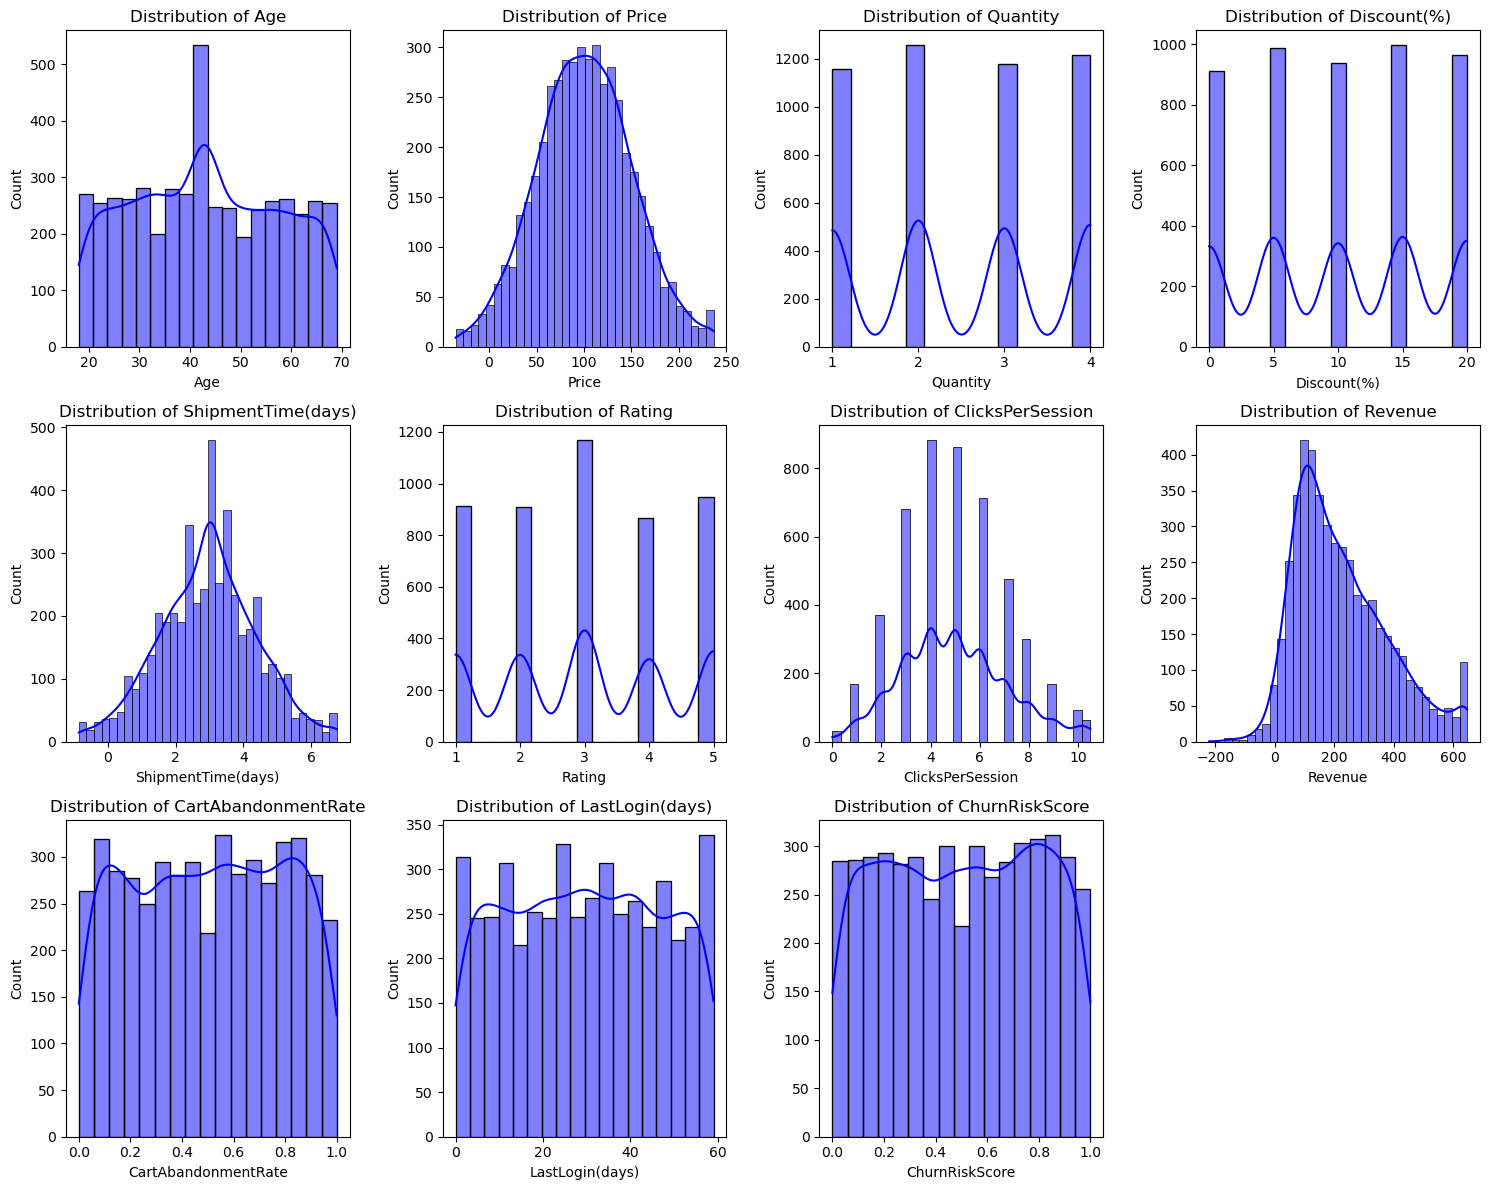

In [7]:
#------Histogram for Numeric features-------
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_col, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], color='blue',kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

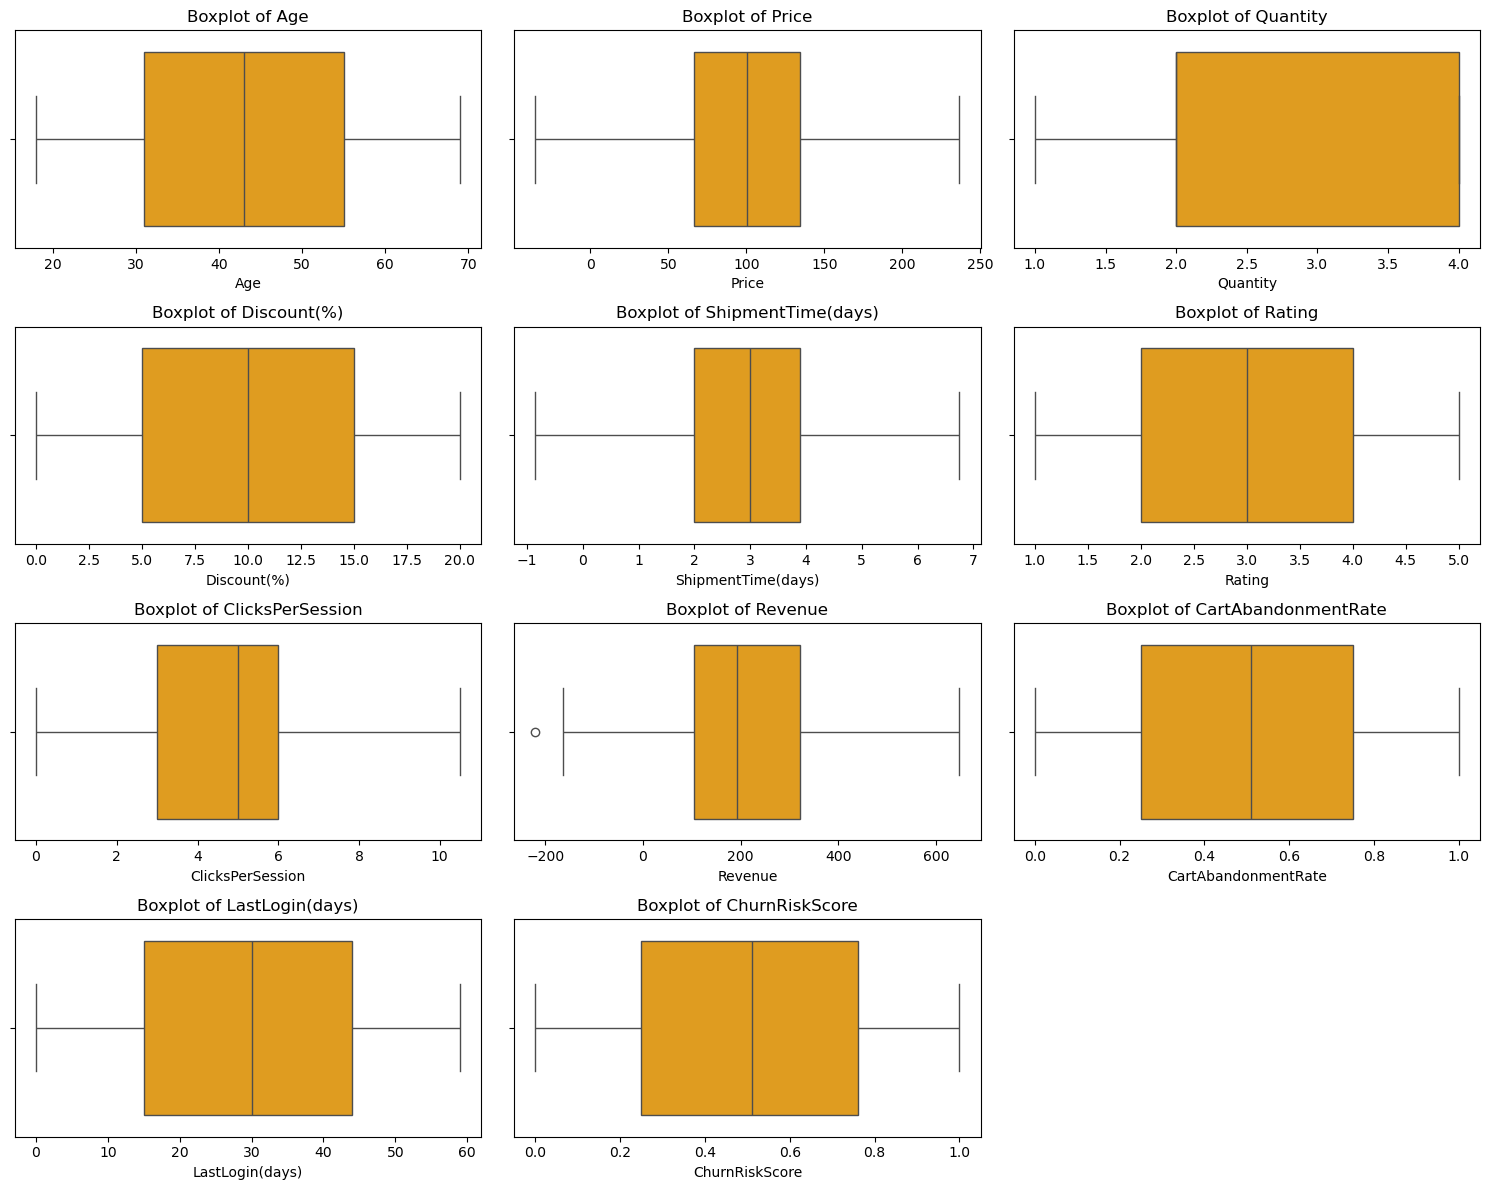

In [8]:
# ------- BOXPLOTS FOR NUMERIC FEATURES -------
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_col, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col],color="Orange")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

## COUNTPLOT FOR CAT COLS

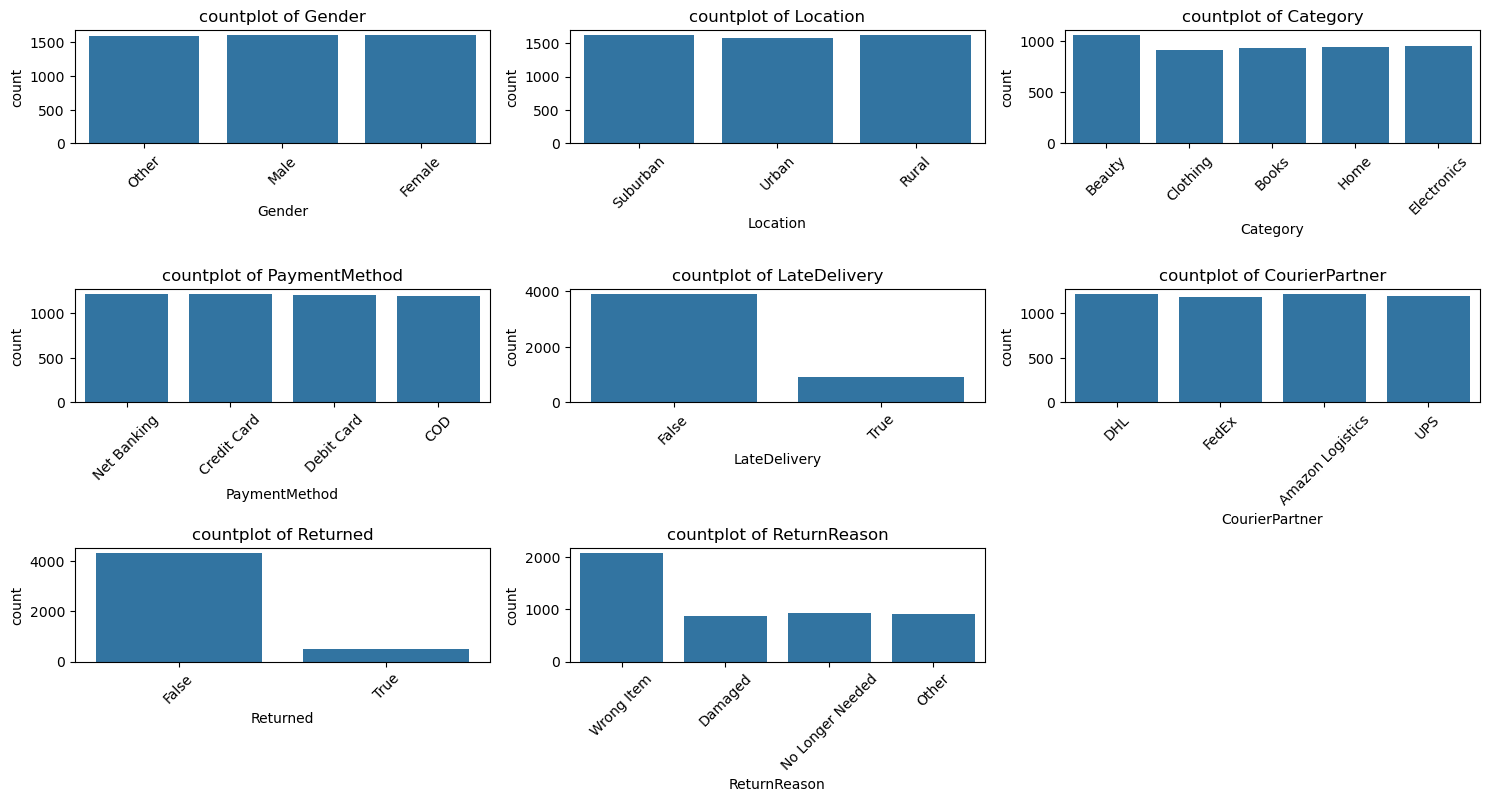

In [9]:
plt.figure(figsize = (15,12))
for i, col in enumerate(cat_col, 1):
    if df[col].nunique() < 25:
        plt.subplot(5,3,i)
        sns.countplot(data=df, x = col)
        plt.xticks(rotation = 45)
        plt.title(f"countplot of {col}")
plt.tight_layout()
plt.show()

## 2. BIVARIATE ANALYSIS (Scatteer plot)

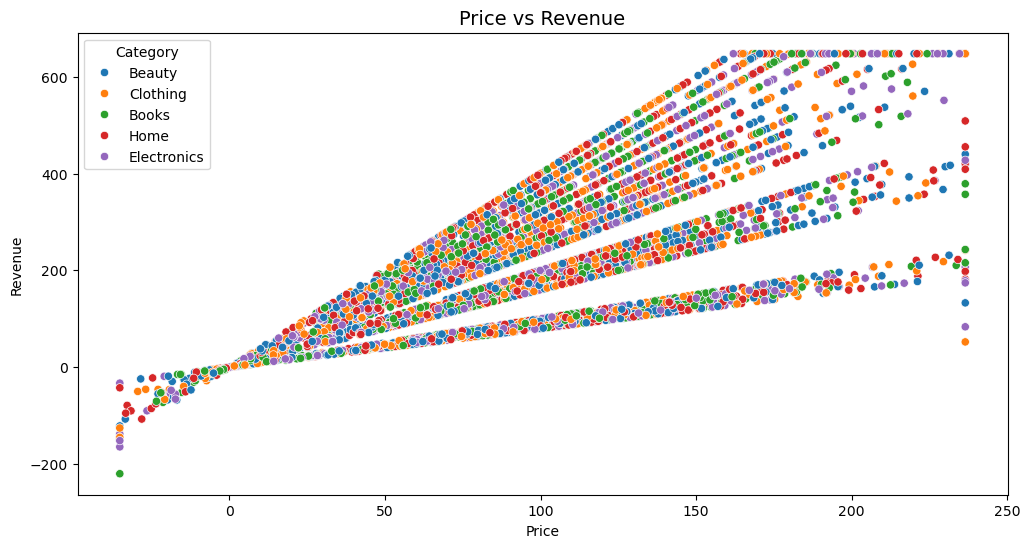

In [24]:
plt.figure(figsize = (12,6))
sns.scatterplot(data = df,x ="Price", y = "Revenue",hue = "Category")
plt.title("Price vs Revenue",fontsize=14)
plt.show()

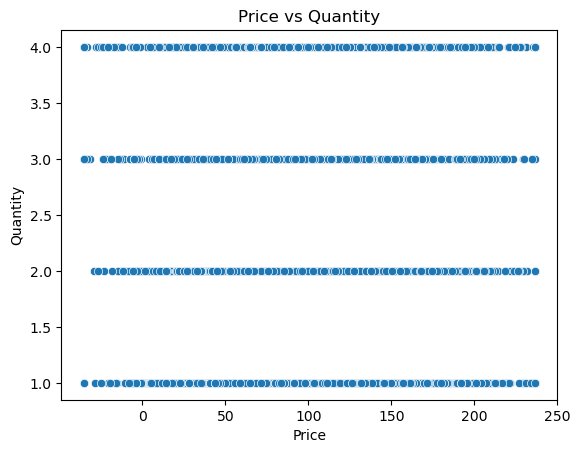

In [14]:
plt.figure()
sns.scatterplot(x='Price', y='Quantity',data=df)
plt.title('Price vs Quantity')
plt.show()


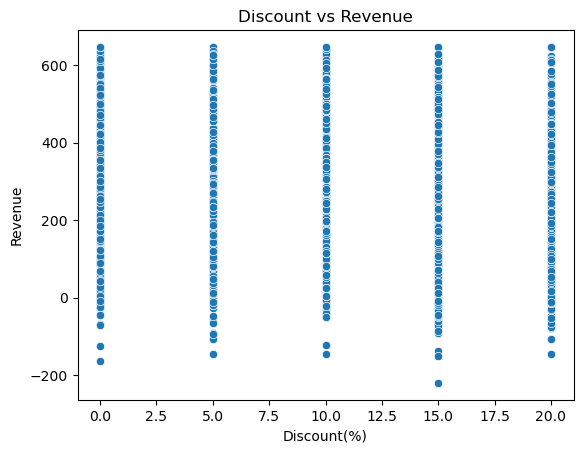

In [15]:
plt.figure()
sns.scatterplot(x='Discount(%)', y='Revenue', data=df)
plt.title('Discount vs Revenue')
plt.show()


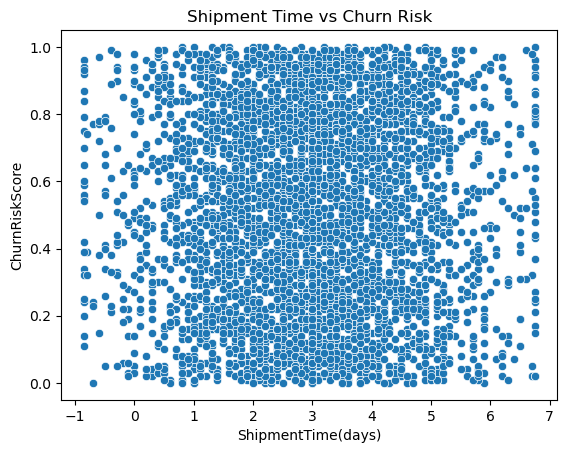

In [17]:
plt.figure()
sns.scatterplot(x='ShipmentTime(days)', y='ChurnRiskScore', data=df)
plt.title('Shipment Time vs Churn Risk')
plt.show()


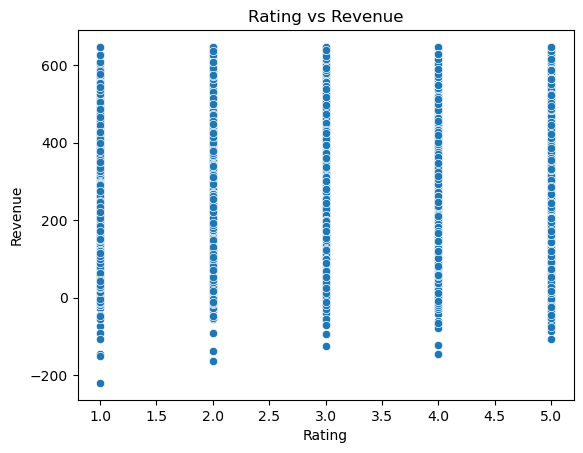

In [22]:
plt.figure()
sns.scatterplot(x='Rating', y='Revenue',data=df)
plt.title('Rating vs Revenue')
plt.show()


## 3. MULTIVARIATE ANALYSIS

In [129]:
## Correlation Heatmap

In [130]:
correlation = df[num_col].corr()


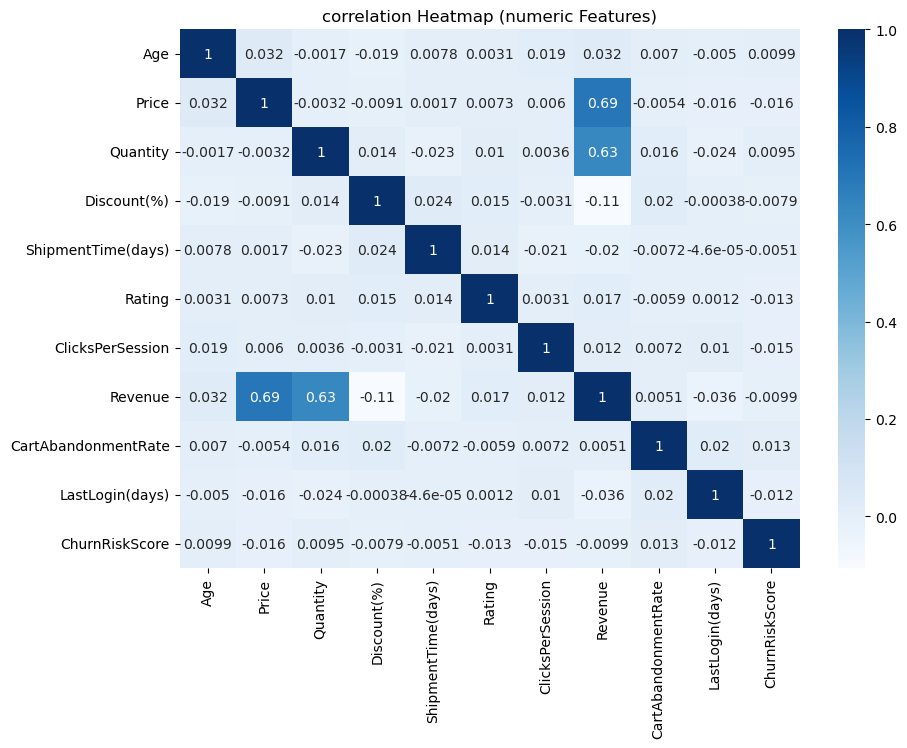

In [26]:
plt.figure(figsize = (10,7))
sns.heatmap(df[num_col].corr(), annot = True, cmap = "Blues")
plt.title("correlation Heatmap (numeric Features)")
plt.show()

In [132]:
## PAIRPLOT

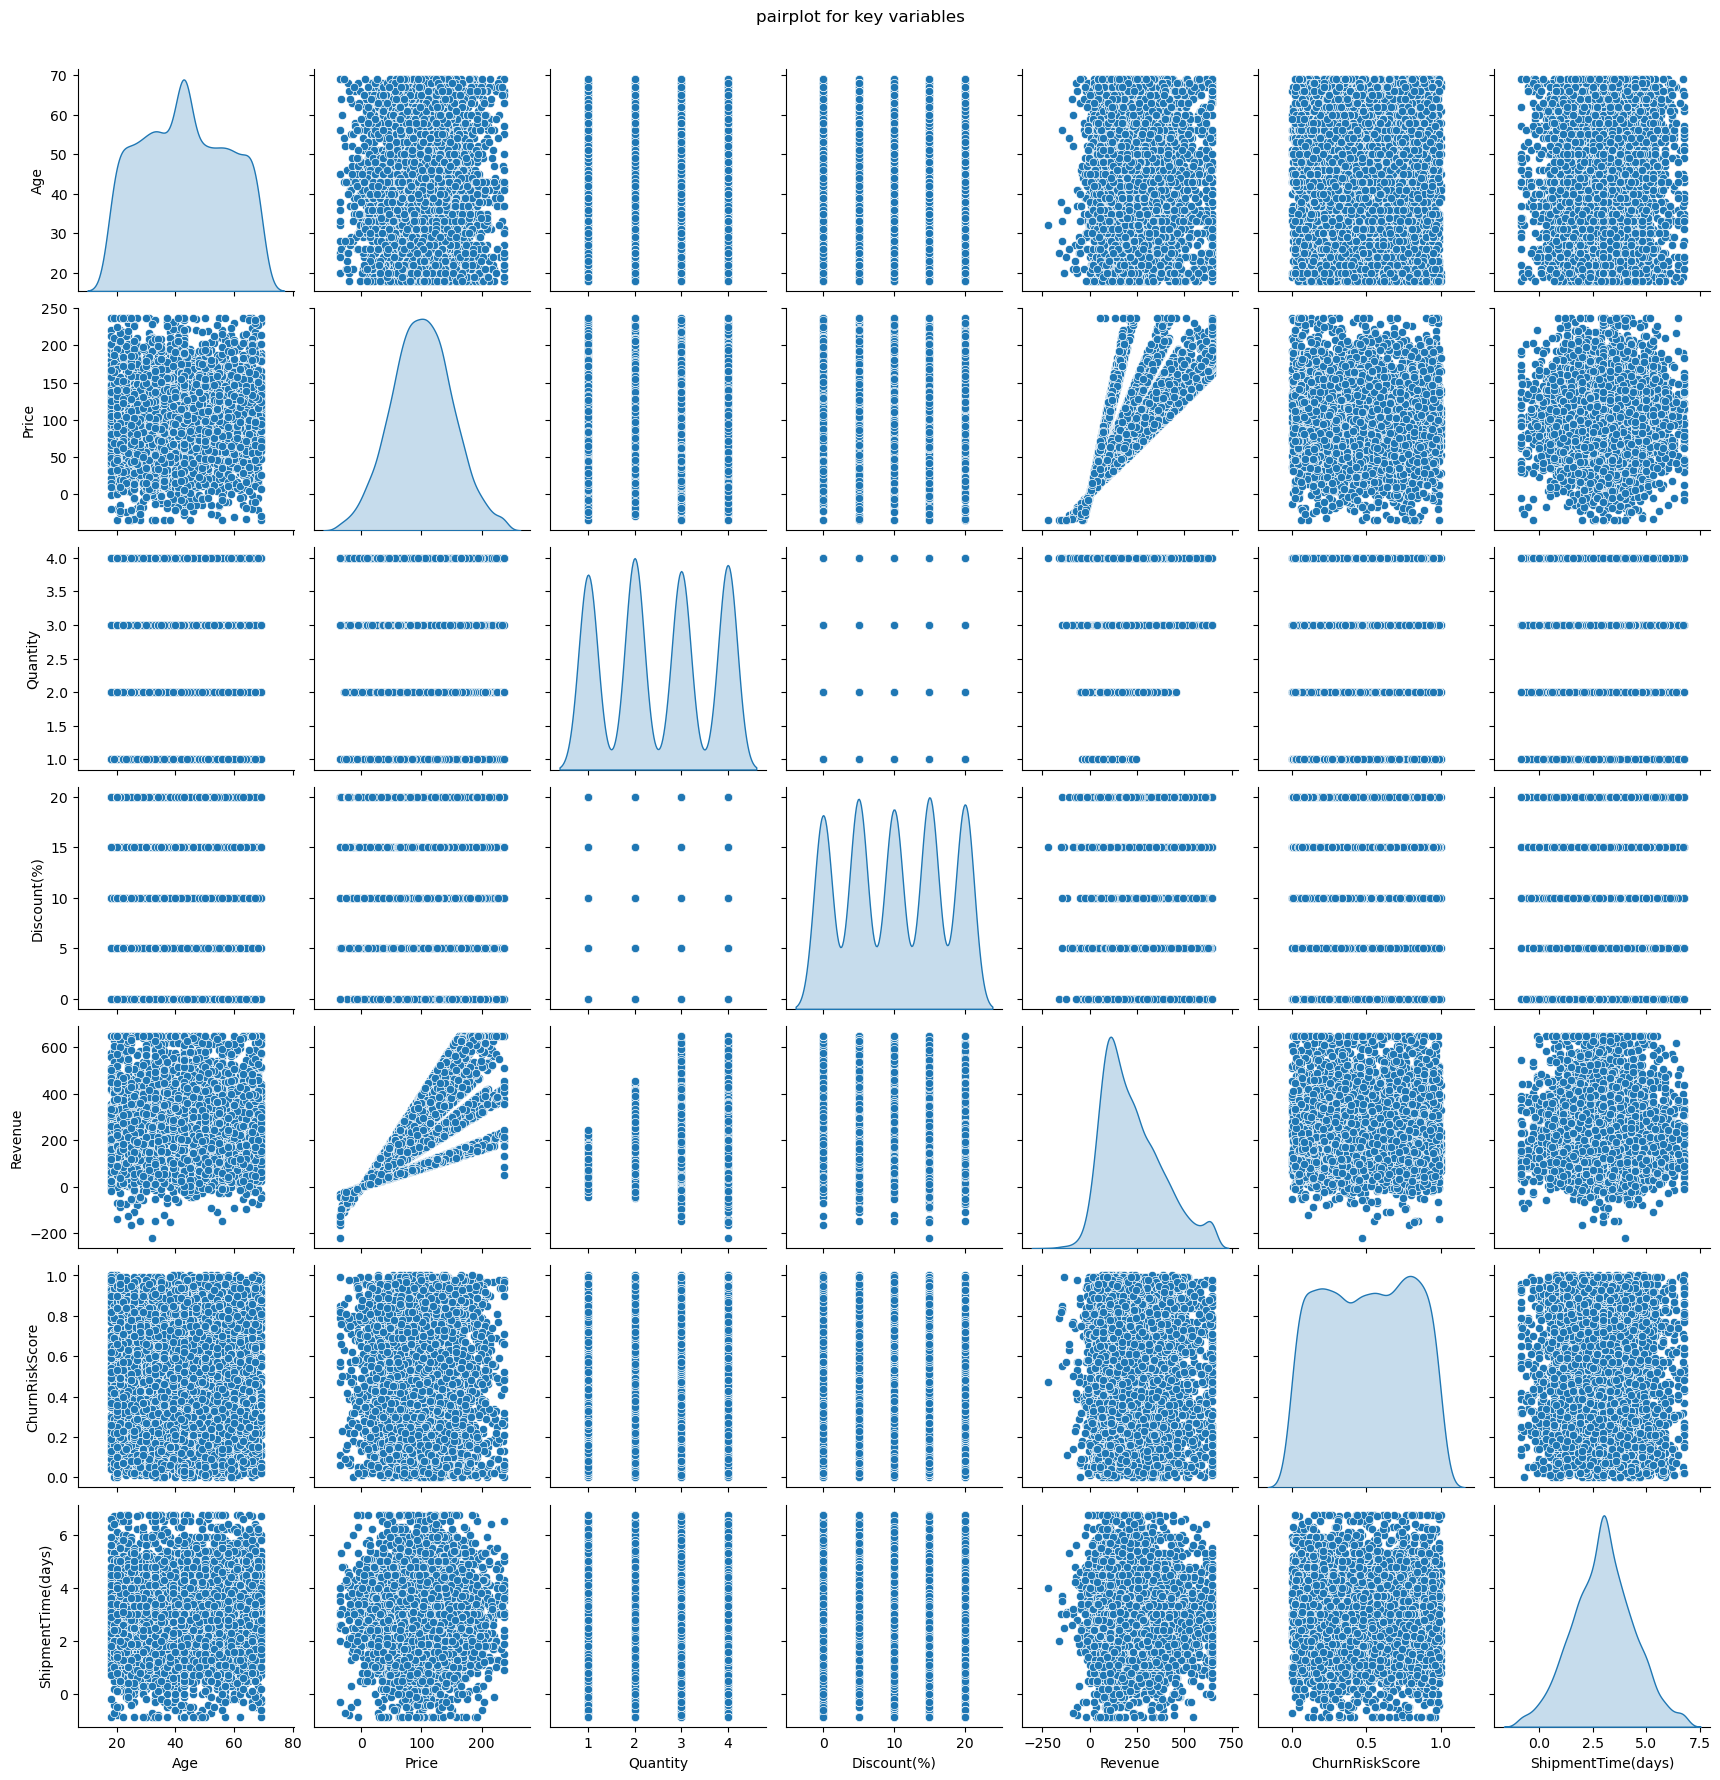

In [21]:
selected_cols= ['Age','Price','Quantity','Discount(%)','Revenue','ChurnRiskScore','ShipmentTime(days)']
sns.pairplot(df[selected_cols].dropna(), diag_kind = "kde")
plt.suptitle('pairplot for key variables',y = 1.02)
plt.show()